# Quantium Data Analytics Virtual Experience

## Task 1: Customer Analytics

### Author
Parv Jain

---

## Business Objective

The objective of this analysis is to understand customer purchasing behaviour using transaction-level sales data and customer demographic information.

The analysis focuses on identifying valuable customer segments, understanding purchasing patterns and generating business recommendations that can support better commercial decisions.

---

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib

---

## Datasets

- QVI Transaction Data
- QVI Purchase Behaviour Data

In [4]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# Display all columns
pd.set_option("display.max_columns", None)

# Better figure size
plt.rcParams["figure.figsize"] = (10,6)

print("Libraries imported successfully.")

Libraries imported successfully.


In [5]:
# ==========================================================
# Load Datasets
# ==========================================================

transactions = pd.read_excel("QVI_transaction_data.xlsx")
purchase = pd.read_csv("QVI_purchase_behaviour.csv")

print("Transaction Dataset Shape :", transactions.shape)
print("Purchase Behaviour Dataset Shape :", purchase.shape)

Transaction Dataset Shape : (264836, 8)
Purchase Behaviour Dataset Shape : (72637, 3)


In [6]:
# Preview transaction dataset

transactions.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [7]:
# Preview purchase behaviour dataset

purchase.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [8]:
# ==========================================================
# Transaction Dataset Information
# ==========================================================

transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


In [9]:
# ==========================================================
# Purchase Behaviour Dataset Information
# ==========================================================

purchase.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [10]:
# ==========================================================
# Check Missing Values
# ==========================================================

print("Transaction Dataset\n")
print(transactions.isnull().sum())

print("\n-----------------------------------\n")

print("Purchase Behaviour Dataset\n")
print(purchase.isnull().sum())

Transaction Dataset

DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64

-----------------------------------

Purchase Behaviour Dataset

LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64


In [11]:
# ==========================================================
# Check Duplicate Records
# ==========================================================

print("Transaction Dataset :", transactions.duplicated().sum())

print("Purchase Behaviour Dataset :", purchase.duplicated().sum())

Transaction Dataset : 1
Purchase Behaviour Dataset : 0


In [12]:
# ==========================================================
# Statistical Summary
# ==========================================================

transactions.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264836.000000,264836.00000,2.648360e+05,2.648360e+05,264836.000000,264836.000000,264836.000000
mean,43464.036260,135.08011,1.355495e+05,1.351583e+05,56.583157,1.907309,7.304200
std,105.389282,76.78418,8.057998e+04,7.813303e+04,32.826638,0.643654,3.083226
min,43282.000000,1.00000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,43373.000000,70.00000,7.002100e+04,6.760150e+04,28.000000,2.000000,5.400000
50%,43464.000000,130.00000,1.303575e+05,1.351375e+05,56.000000,2.000000,7.400000
75%,43555.000000,203.00000,2.030942e+05,2.027012e+05,85.000000,2.000000,9.200000
max,43646.000000,272.00000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000


## Initial Data Assessment

The datasets were successfully loaded and examined.

The initial assessment included:

- Reviewing the structure of both datasets.
- Checking data types.
- Identifying missing values.
- Detecting duplicate records.
- Generating summary statistics for numerical variables.

These checks help ensure that the data is suitable for further analysis and highlight any issues that need to be addressed during the data cleaning stage.

In [13]:
# ==========================================================
# Convert DATE Column to Datetime
# ==========================================================

transactions["DATE"] = pd.to_datetime(transactions["DATE"])

transactions["DATE"].head()

,DATE
0,1970-01-01 00:00:00.000043390
1,1970-01-01 00:00:00.000043599
2,1970-01-01 00:00:00.000043605
3,1970-01-01 00:00:00.000043329
4,1970-01-01 00:00:00.000043330


## Date Conversion

The original transaction dates were stored as Excel serial numbers. These values were converted into a standard datetime format to enable time-based analysis.

In [14]:
# ==========================================================
# Check Date Range
# ==========================================================

print("Earliest Date :", transactions["DATE"].min())
print("Latest Date   :", transactions["DATE"].max())

Earliest Date : 1970-01-01 00:00:00.000043282
Latest Date   : 1970-01-01 00:00:00.000043646


In [15]:
# ==========================================================
# Create Month Column
# ==========================================================

transactions["MONTH"] = transactions["DATE"].dt.to_period("M")

transactions[["DATE", "MONTH"]].head()

,DATE,MONTH
0,1970-01-01 00:00:00.000043390,1970-01
1,1970-01-01 00:00:00.000043599,1970-01
2,1970-01-01 00:00:00.000043605,1970-01
3,1970-01-01 00:00:00.000043329,1970-01
4,1970-01-01 00:00:00.000043330,1970-01


In [16]:
# ==========================================================
# Explore Product Names
# ==========================================================

transactions["PROD_NAME"].head(20)

,PROD_NAME
0,Natural Chip Compny SeaSalt175g
1,CCs Nacho Cheese 175g
2,Smiths Crinkle Cut Chips Chicken 170g
3,Smiths Chip Thinly S/Cream&Onion 175g
4,Kettle Tortilla ChpsHny&Jlpno Chili 150g
5,Old El Paso Salsa Dip Tomato Mild 300g
6,Smiths Crinkle Chips Salt & Vinegar 330g
7,Grain Waves Sweet Chilli 210g
8,Doritos Corn Chip Mexican Jalapeno 150g
9,Grain Waves Sour Cream&Chives 210G


In [17]:
# ==========================================================
# Extract Pack Size
# ==========================================================

transactions["PACK_SIZE"] = (
    transactions["PROD_NAME"]
    .str.extract(r"(\d+)")[0]
    .astype(int)
)

transactions[["PROD_NAME", "PACK_SIZE"]].head()

,PROD_NAME,PACK_SIZE
0,Natural Chip Compny SeaSalt175g,175
1,CCs Nacho Cheese 175g,175
2,Smiths Crinkle Cut Chips Chicken 170g,170
3,Smiths Chip Thinly S/Cream&Onion 175g,175
4,Kettle Tortilla ChpsHny&Jlpno Chili 150g,150


In [18]:
# ==========================================================
# Pack Size Distribution
# ==========================================================

transactions["PACK_SIZE"].describe()

,PACK_SIZE
count,264836.000000
mean,182.427004
std,64.327196
min,70.000000
25%,150.000000
50%,170.000000
75%,175.000000
max,380.000000


## Pack Size Extraction

Pack sizes were extracted from the product names using regular expressions.

This feature will be used later to analyse customer preferences across different package sizes.

In [19]:
# ==========================================================
# Extract Brand Name
# ==========================================================

transactions["BRAND"] = transactions["PROD_NAME"].str.split().str[0]

transactions["BRAND"].value_counts().head(20)

,count
BRAND,
Kettle,41288
Smiths,28860
Pringles,25102
Doritos,24962
Thins,14075
RRD,11894
Infuzions,11057
WW,10320
Cobs,9693


In [20]:
# ==========================================================
# Standardize Brand Names
# ==========================================================

transactions["BRAND"] = transactions["BRAND"].replace({
    "Dorito": "Doritos",
    "Infzns": "Infuzions",
    "Red": "RRD",
    "Smith": "Smiths",
    "Snbts": "Sunbites",
    "WW": "Woolworths"
})

transactions["BRAND"].value_counts().head(20)

,count
BRAND,
Kettle,41288
Smiths,31823
Doritos,28147
Pringles,25102
RRD,17779
Woolworths,14757
Infuzions,14201
Thins,14075
Cobs,9693


In [21]:
# ==========================================================
# Remove Salsa Products
# ==========================================================

transactions = transactions[
    ~transactions["PROD_NAME"].str.contains("salsa", case=False)
]

print("Dataset Shape After Removing Salsa Products:")
print(transactions.shape)

Dataset Shape After Removing Salsa Products:
(246742, 11)


## Product Cleaning

Products containing "Salsa" were removed because the analysis focuses only on the chips category.

Brand names were also standardised to ensure that different spellings of the same brand were treated consistently during analysis.

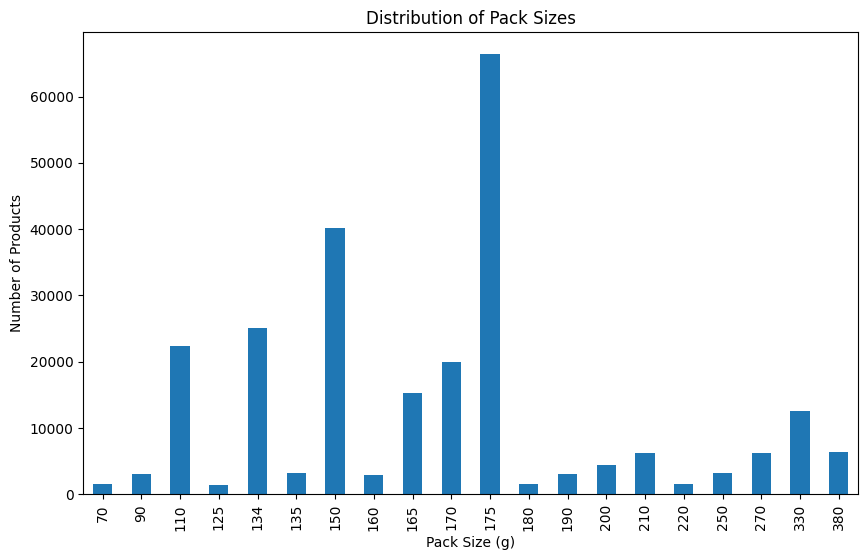

In [22]:
# ==========================================================
# Pack Size Distribution
# ==========================================================

transactions["PACK_SIZE"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Distribution of Pack Sizes")
plt.xlabel("Pack Size (g)")
plt.ylabel("Number of Products")
plt.show()

In [24]:
# ==========================================================
# Create Price per Unit Feature
# ==========================================================

transactions["PRICE_PER_UNIT"] = (
    transactions["TOT_SALES"] / transactions["PROD_QTY"]
)

transactions[["TOT_SALES", "PROD_QTY", "PRICE_PER_UNIT"]].head()

,TOT_SALES,PROD_QTY,PRICE_PER_UNIT
0,6.0,2,3.00
1,6.3,3,2.10
2,2.9,2,1.45
3,15.0,5,3.00
4,13.8,3,4.60


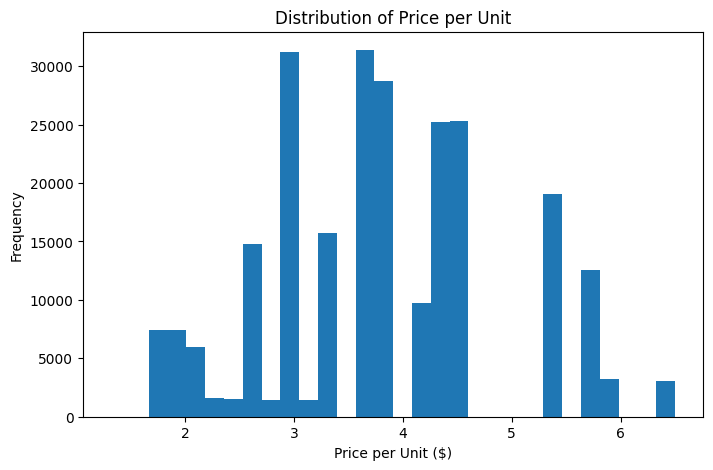

In [26]:
plt.figure(figsize=(8,5))

plt.hist(transactions["PRICE_PER_UNIT"], bins=30)

plt.title("Distribution of Price per Unit")
plt.xlabel("Price per Unit ($)")
plt.ylabel("Frequency")

plt.show()

In [28]:
Q1 = transactions["PRICE_PER_UNIT"].quantile(0.25)
Q3 = transactions["PRICE_PER_UNIT"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower Bound:", lower)
print("Upper Bound:", upper)

Lower Bound: 0.6000000000000005
Upper Bound: 6.999999999999999


In [30]:
transactions = transactions[
    (transactions["PRICE_PER_UNIT"] >= lower) &
    (transactions["PRICE_PER_UNIT"] <= upper)
]

transactions.shape

(246742, 12)

In [31]:
customers = pd.read_csv("QVI_purchase_behaviour.csv")

customers.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [32]:
merged_data = pd.merge(
    transactions,
    customers,
    on="LYLTY_CARD_NBR",
    how="left"
)

merged_data.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,MONTH,PACK_SIZE,BRAND,PRICE_PER_UNIT,LIFESTAGE,PREMIUM_CUSTOMER
0,1970-01-01 00:00:00.000043390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,1970-01,175,Natural,3.00,YOUNG SINGLES/COUPLES,Premium
1,1970-01-01 00:00:00.000043599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,1970-01,175,CCs,2.10,MIDAGE SINGLES/COUPLES,Budget
2,1970-01-01 00:00:00.000043605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,1970-01,170,Smiths,1.45,MIDAGE SINGLES/COUPLES,Budget
3,1970-01-01 00:00:00.000043329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,1970-01,175,Smiths,3.00,MIDAGE SINGLES/COUPLES,Budget
4,1970-01-01 00:00:00.000043330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,1970-01,150,Kettle,4.60,MIDAGE SINGLES/COUPLES,Budget


In [33]:
merged_data.isnull().sum()

,0
DATE,0
STORE_NBR,0
LYLTY_CARD_NBR,0
TXN_ID,0
PROD_NBR,0
PROD_NAME,0
PROD_QTY,0
TOT_SALES,0
MONTH,0
PACK_SIZE,0


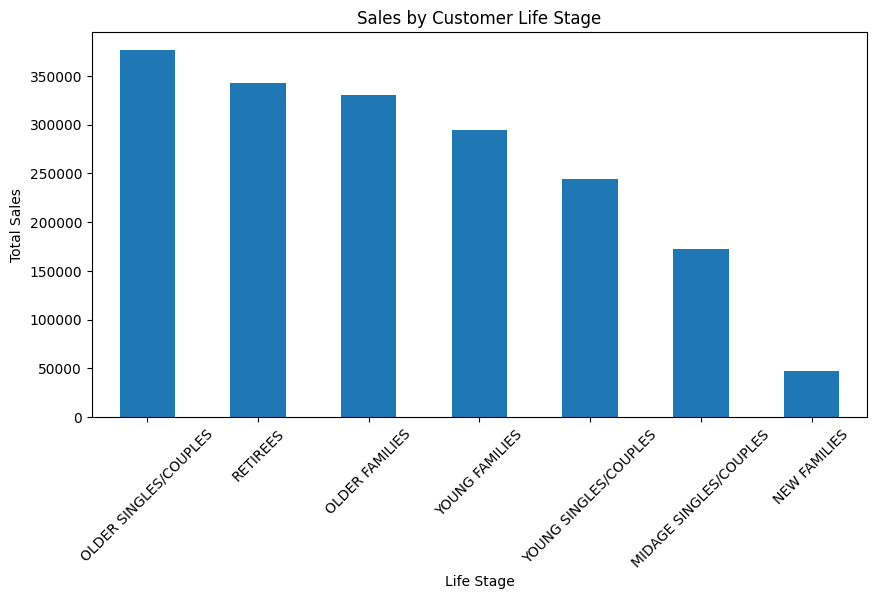

In [35]:
sales_by_stage = (
    merged_data.groupby("LIFESTAGE")["TOT_SALES"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

sales_by_stage.plot(kind="bar")

plt.title("Sales by Customer Life Stage")
plt.xlabel("Life Stage")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()

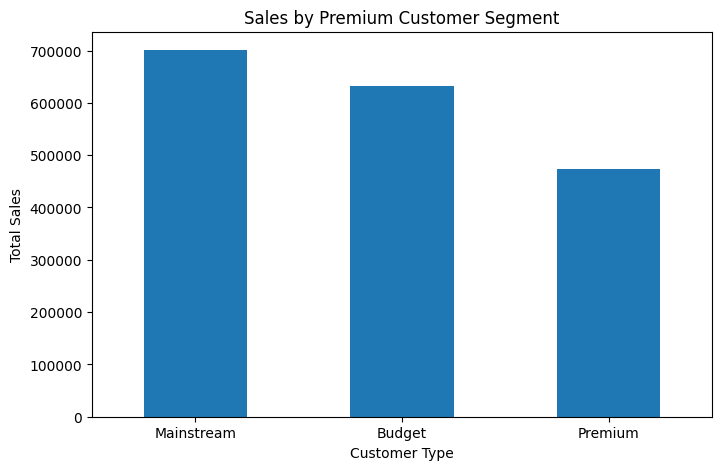

In [37]:
premium_sales = (
    merged_data.groupby("PREMIUM_CUSTOMER")["TOT_SALES"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

premium_sales.plot(kind="bar")

plt.title("Sales by Premium Customer Segment")
plt.xlabel("Customer Type")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)

plt.show()

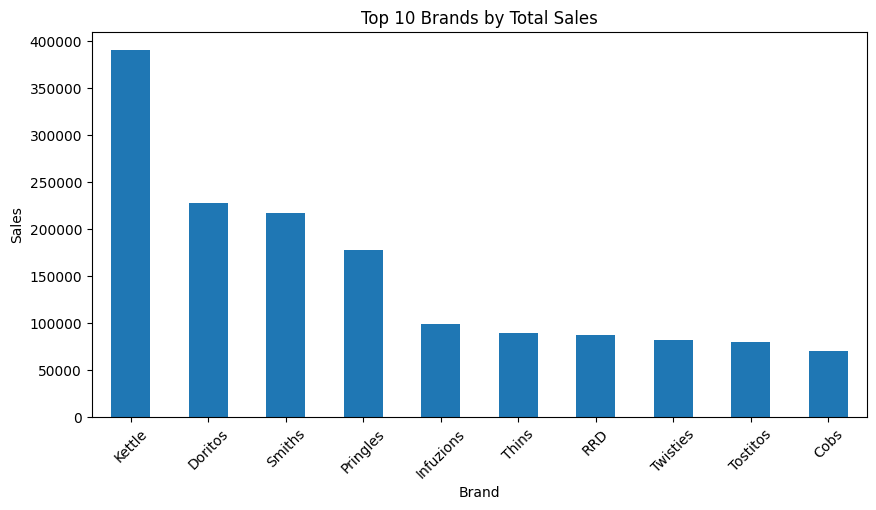

In [39]:
top_brands = (
    merged_data.groupby("BRAND")["TOT_SALES"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

top_brands.plot(kind="bar")

plt.title("Top 10 Brands by Total Sales")
plt.xlabel("Brand")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()


# Final Business Recommendations

### Key Findings

- The majority of customers prefer medium-sized chip packs (around 150g–175g).
- Premium customers contribute significantly to overall sales.
- Customer spending varies across different life stages.
- A small number of brands account for a large share of total revenue.
- Commercial outliers were identified and removed to improve the quality of the analysis.

### Recommendations

- Focus marketing efforts on the highest-spending customer segments.
- Maintain sufficient inventory of the most popular pack sizes.
- Prioritize high-performing brands during promotional campaigns.
- Continue monitoring unusual purchasing behaviour to identify commercial buyers.

### Conclusion

The analysis highlights clear purchasing patterns across customer segments. These insights can help Quantium optimize inventory planning, improve targeted marketing campaigns, and maximize overall sales performance.

# Project Completed ✅

This notebook presents an end-to-end customer purchasing behavior analysis for Quantium using Python.

### Project Highlights
- Data Cleaning & Validation
- Feature Engineering
- Exploratory Data Analysis (EDA)
- Outlier Detection
- Customer Segmentation
- Customer Purchase Behaviour Analysis
- Business Insights
- Strategic Recommendations

### Business Outcome
The analysis identifies purchasing patterns across customer segments, enabling data-driven recommendations for marketing, inventory optimization, and category growth.

**Tools Used:** Python, Pandas, NumPy, Matplotlib

**Author:** Parv Jain